In [30]:
import _007_EXP_model_validation
import importlib
importlib.reload(_007_EXP_model_validation)
from _007_EXP_model_validation import mm_permiability_from_path, plot_side_by_side_histograms, get_mm_empirical_distribution, get_md_empiricial_distribution

import numpy as np
import pickle
import matplotlib.pyplot as plt
import os
import multiprocessing as mp
import seaborn as sns

In [6]:
permiability_from_path(matrix_path=f"data/transition_matrices/interactions-150-180-symmetric-{100}ns.pickle",
                       n_sims=250, # 5 molecules = 1 uM, 250 molecules = 50 uM
                       sim_length=300) # 10000 steps = 1 ms, 1000 steps = 100 us

17

In [14]:
for i in [0, 1, 2, 4, 8, 16, 32, 64]:
    perm = permiability_from_path(matrix_path=f"/cs/usr/roi.eliasian/LabFolder/Master/NPC-markov/data/transition_matrices/interactions-150-180-sym-diag+{i}.pickle",
                       n_sims=250, # 5 molecules = 1 uM, 250 molecules = 50 uM
                       sim_length=300) # 10000 steps = 1 ms, 1000 steps = 100 us
    print(f"Permeability for {i} diag: {perm}")

Permeability for 0 diag: 300
Permeability for 1 diag: 316
Permeability for 2 diag: 280
Permeability for 4 diag: 286
Permeability for 8 diag: 311
Permeability for 16 diag: 308
Permeability for 32 diag: 297
Permeability for 64 diag: 314


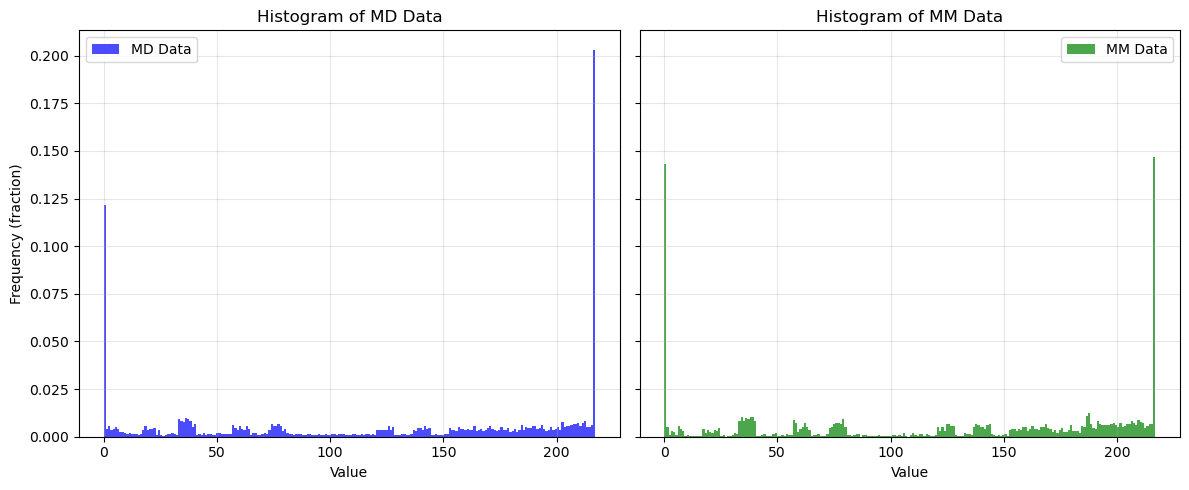

In [31]:
# state distribution

# load tm

md_data = get_md_empiricial_distribution(traj_path='data/categorized/interactions-150-180-100ns.pickle',
                                         n_series=1000,
                                         series_len=300)
mm_data = get_mm_empirical_distribution(tm_path="data/transition_matrices/mem-with-0.1init/interactionsmem-window32-p0.1-150-180-100ns.pickle",
                                        n_series=1000,
                                        series_len=1000,
                                        mem=True,
                                        init_dist=None)


# with open(f'data/transition_matrices/interactionsmem-window{32}-p{0.1}-150-180-100ns.pickle', "rb") as f:
# # with open("data/transition_matrices/interactions-150-180-symmetric-100ns.pickle", "rb") as f:
# # with open(f"data/transition_matrices/interactions-150-180-symmetric-100ns-0init.pickle", "rb") as f:
#     tm, states = pickle.load(f)
    
# tm, states = z_order_interactionsmem_transition_matrix(tm, states)

# # load real data
# with open ('data/categorized/interactions-150-180-100ns.pickle', 'rb') as f:
#     data = pickle.load(f)


    
    
plot_side_by_side_histograms(md_data, mm_data, bins=218, labels=('MD Data', 'MM Data'), titles=('Histogram of MD Data', 'Histogram of MM Data'), figsize=(12, 5))

In [4]:

def multi_compare_transports():
    # load real data
    with open ('data/categorized/interactions-150-180-100ns.pickle', 'rb') as f:
        real_data = pickle.load(f)
        
    # convert data to numbers by z axis
    with open(f"data/anchor_coordinates.pickle", "rb") as f:
        anchor_coordinates = pickle.load(f)
    anchor_coordinates = dict(sorted(anchor_coordinates.items(), key=lambda x: x[1][2]))
    new_states = ["nuc"] + list(anchor_coordinates.keys()) + ["cyt"]
    state_to_index = {state: i for i, state in enumerate(new_states)}
    vectorized_lookup = np.vectorize(lambda x: state_to_index.get(x, 0))  # 0 is default if key not found
    real_data = vectorized_lookup(real_data)

    # calculate init dist
    def count_values(series):
        return np.bincount(series, minlength=218)# This gives counts for values 0 to 217
    norm_data = np.apply_along_axis(count_values, axis=1, arr=real_data)
    norm_data = np.sum(norm_data, axis=0)
    norm_data = norm_data / np.sum(norm_data)
    
    layer_names = ["Nuc", "Nup2", "Nup60", "Nup2", "Nup60", "Nup1", "Nup145", 
                "Nup49", "Nsp1", "Nup49", "Nsp1", "Nup57", "Nup145", 
                "Nup57", "Nup57", "Nup57", "Nsp1", "Nup49", "Nsp1", 
                "Nup49", "Nup100", "Nup159", "Nup100", "Nup159", 
                "Nsp1", "Nsp1", "Nup116", "Nup116", "Cyt"]
    n_layers = len(layer_names)
    md_transports = np.zeros((n_layers+2, n_layers+2))
    markov_transports = np.zeros((n_layers+2, n_layers+2))

    
    args_list = [(real_data, norm_data, bottom_state, top_state) for top_state in range(31) for bottom_state in range(top_state)]
    num_cpus = len(os.sched_getaffinity(0))
    print(f"Using {num_cpus} CPUs")
    with mp.Pool(processes=num_cpus) as pool:
        results = pool.map(compare_tranports_wrapper, args_list)
    print(results[0])
    for md_t, markov_t, bottom_state, top_state in results:
        md_transports[bottom_state, top_state], markov_transports[bottom_state, top_state] = md_t, markov_t
    return md_transports, markov_transports

def compare_tranports_wrapper(args):
    return (*compare_tranports(*args), args[2], args[3])

def compare_tranports(real_data, init_dist, bottom_state, top_state):
    if bottom_state == 0:
        bottom_states = [0]
    elif bottom_state == 30:
        bottom_states = [217]
    else:
        bottom_states = [bottom_state*8 + i for i in range(1, 9)]
    if top_state == 0:
        top_states = [0]
    elif top_state == 30:
        top_states = [217]
    else:
        top_states = [top_state*8 + i for i in range(1, 9)]
    
    # count real transports
    md_transports = 0
    for i in range(real_data.shape[0]):
        md_transports += calc_transports(real_data[i],
                                        bottom_states=bottom_states,
                                        top_states=top_states)
        
    # count synthetic transports
    markov_trasports = permiability_from_path(matrix_path="/cs/usr/roi.eliasian/LabFolder/Master/NPC-markov/data/transition_matrices/interactions-150-180-sym-diag+0.pickle",
                        n_sims=1, # 5 molecules = 1 uM, 250 molecules = 50 uM
                        sim_length=300, # 10000 steps = 1 ms, 1000 steps = 100 us
                        bottom_states=bottom_states,
                        top_states=top_states,
                        init_dist=init_dist) 
    return md_transports, markov_trasports
    
# 55 1075
    

In [22]:
md_transports, markov_trasports = multi_compare_transports()

Using 16 CPUs
(17136, 3, 0, 1)


In [14]:
# get the rows of real transport where both 0 and 217 appear
def get_rows_with_both_0_and_217(data):
    rows = []
    for i in range(data.shape[0]):
        if 0 in data[i] and (217 in data[i] or 216 in data[i] or 215 in data[i] or 214 in data[i] or 213 in data[i]):
            rows.append(i)
    return rows
rows = get_rows_with_both_0_and_217(real_data)

In [10]:
a = permiability_from_path(
                        matrix_path="/cs/usr/roi.eliasian/LabFolder/Master/NPC-markov/data/transition_matrices/interactionsmem-150-180-sym-100ns.pickle",
                        # matrix_path="/cs/usr/roi.eliasian/LabFolder/Master/NPC-markov/data/transition_matrices/interactions-150-180-sym-diag+0.pickle",
                        n_sims=250, # 5 molecules = 1 uM, 250 molecules = 50 uM
                        sim_length=300, # 10000 steps = 1 ms, 1000 steps = 100 us
                        bottom_states=[0,218],
                        top_states=[217, 435],
                        init_dist=None,
                        mem=True
                        ) 

b = permiability_from_path(
                        # matrix_path="/cs/usr/roi.eliasian/LabFolder/Master/NPC-markov/data/transition_matrices/interactionsmem-150-180-sym-100ns.pickle",
                        matrix_path="/cs/usr/roi.eliasian/LabFolder/Master/NPC-markov/data/transition_matrices/interactions-150-180-sym-diag+0.pickle",
                        n_sims=250, # 5 molecules = 1 uM, 250 molecules = 50 uM
                        sim_length=300, # 10000 steps = 1 ms, 1000 steps = 100 us
                        bottom_states=[0,218],
                        top_states=[217, 435],
                        init_dist=None,
                        mem=False
                        )

print(a)
print(b) 

131
345


In [ ]:
window_sizes = [2, 4, 8, 16, 32, 64]
ps = [0.1, 0.3, 0.5, 0.7, 0.9]

n_windows = len(window_sizes)
n_ps = len(ps)

results = np.zeros((n_windows, n_ps))
for i, window_size in enumerate(window_sizes):
    for j, p in enumerate(ps):
        print(f"Window size: {window_size}, p: {p}")
        permiablity = mm_permiability_from_path(
                        matrix_path=f'data/transition_matrices/interactionsmem-window{window_size}-p{p}-150-180-100ns.pickle',
                        n_sims=250, # 5 molecules = 1 uM, 250 molecules = 50 uM
                        sim_length=300, # 10000 steps = 1 ms, 1000 steps = 100 us
                        bottom_states=[0,218],
                        top_states=[217, 435],
                        init_dist=None,
                        mem=True
                        )
        results[i, j] = permiablity
        
with open("data/permiabilities/interactionsmem-window-p-150-180-100ns.pickle", "wb") as f:
    pickle.dump(results, f)

Window size: 2, p: 0.1
Window size: 2, p: 0.3
Window size: 2, p: 0.5
Window size: 2, p: 0.7
Window size: 2, p: 0.9
Window size: 4, p: 0.1
Window size: 4, p: 0.3
Window size: 4, p: 0.5
Window size: 4, p: 0.7
Window size: 4, p: 0.9
Window size: 8, p: 0.1
Window size: 8, p: 0.3
Window size: 8, p: 0.5
Window size: 8, p: 0.7
Window size: 8, p: 0.9
Window size: 16, p: 0.1
Window size: 16, p: 0.3
Window size: 16, p: 0.5
Window size: 16, p: 0.7
Window size: 16, p: 0.9
Window size: 32, p: 0.1
Window size: 32, p: 0.3
Window size: 32, p: 0.5
Window size: 32, p: 0.7
Window size: 32, p: 0.9
Window size: 64, p: 0.1
Window size: 64, p: 0.3
Window size: 64, p: 0.5
Window size: 64, p: 0.7
Window size: 64, p: 0.9


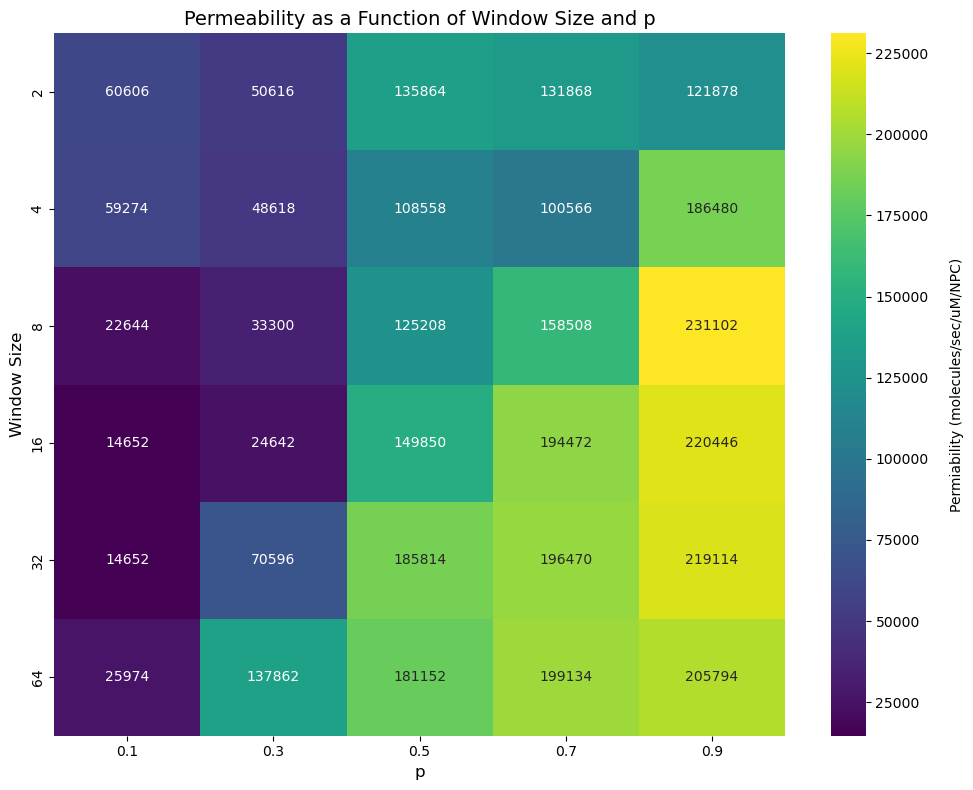

In [32]:
with open("data/permiabilities/interactionsmem-window-p-150-180-100ns.pickle", "rb") as f:
    results = pickle.load(f)

# Create figure with appropriate size
plt.figure(figsize=(10, 8))

# Create heatmap
heatmap = sns.heatmap(results, 
            xticklabels=[f"{p}" for p in ps],
            yticklabels=[f"{w}" for w in window_sizes],
            annot=True,  # Show numerical values in cells
            cmap="viridis",  # Choose an appropriate colormap
            fmt=".0f")  # Format annotations as scientific notation

# Add labels and title
plt.xlabel('p', fontsize=12)
plt.ylabel('Window Size', fontsize=12)
plt.title('Permeability as a Function of Window Size and p', fontsize=14)
cbar = heatmap.collections[0].colorbar
cbar.set_label('Permiability (molecules/sec/uM/NPC)', rotation=90, labelpad=15)


# Improve readability
plt.tight_layout()

# Show the plot
plt.show()

In [5]:
window_sizes = [2, 4, 8, 16, 32, 64]
ps = [0.1, 0.3, 0.5, 0.7, 0.9]

n_windows = len(window_sizes)
n_ps = len(ps)

results = np.zeros((n_windows, n_ps))
for i, window_size in enumerate(window_sizes):
    for j, p in enumerate(ps):
        print(f"Window size: {window_size}, p: {p}")
        permiablity = permiability_from_path(
                        matrix_path=f'data/transition_matrices/mem-with-0.1init/interactionsmem-window{window_size}-p{p}-150-180-100ns.pickle',
                        n_sims=250, # 5 molecules = 1 uM, 250 molecules = 50 uM
                        sim_length=300, # 10000 steps = 1 ms, 1000 steps = 100 us
                        bottom_states=[0,218],
                        top_states=[217, 435],
                        init_dist=None,
                        mem=True
                        )
        results[i, j] = permiablity * 666
        # n / 30 us / 50 uM / 1
        # = n / 3e-5 s / 50 uM
        # = 0.02 n / 3e-5 s / uM
        # = 666 * n / s / uM / NPC
        
with open("data/permiabilities/interactionsmem-window-p-150-180-100ns-0.1init.pickle", "wb") as f:
    pickle.dump(results, f)

Window size: 2, p: 0.1
Window size: 2, p: 0.3
Window size: 2, p: 0.5
Window size: 2, p: 0.7
Window size: 2, p: 0.9
Window size: 4, p: 0.1
Window size: 4, p: 0.3
Window size: 4, p: 0.5
Window size: 4, p: 0.7
Window size: 4, p: 0.9
Window size: 8, p: 0.1
Window size: 8, p: 0.3
Window size: 8, p: 0.5
Window size: 8, p: 0.7
Window size: 8, p: 0.9
Window size: 16, p: 0.1
Window size: 16, p: 0.3
Window size: 16, p: 0.5
Window size: 16, p: 0.7
Window size: 16, p: 0.9
Window size: 32, p: 0.1
Window size: 32, p: 0.3
Window size: 32, p: 0.5
Window size: 32, p: 0.7
Window size: 32, p: 0.9
Window size: 64, p: 0.1
Window size: 64, p: 0.3
Window size: 64, p: 0.5
Window size: 64, p: 0.7
Window size: 64, p: 0.9


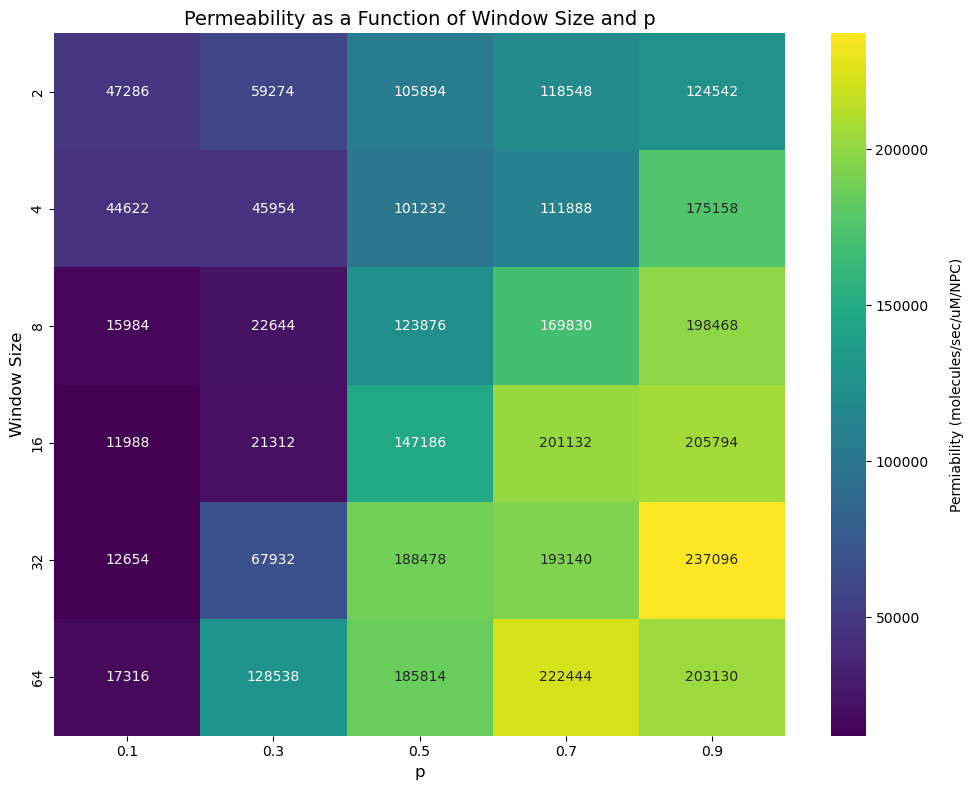

In [7]:
with open("data/permiabilities/interactionsmem-window-p-150-180-100ns-0.1init.pickle", "rb") as f:
    results = pickle.load(f)

# Create figure with appropriate size
plt.figure(figsize=(10, 8))

# Create heatmap
heatmap = sns.heatmap(results, 
            xticklabels=[f"{p}" for p in ps],
            yticklabels=[f"{w}" for w in window_sizes],
            annot=True,  # Show numerical values in cells
            cmap="viridis",  # Choose an appropriate colormap
            fmt=".0f")  # Format annotations as scientific notation

# Add labels and title
plt.xlabel('p', fontsize=12)
plt.ylabel('Window Size', fontsize=12)
plt.title('Permeability as a Function of Window Size and p', fontsize=14)
cbar = heatmap.collections[0].colorbar
cbar.set_label('Permiability (molecules/sec/uM/NPC)', rotation=90, labelpad=15)


# Improve readability
plt.tight_layout()

# Show the plot
plt.show()